# MINTverse in one region

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CosmoNaught/MINTverse/blob/main/MINTverse-tutorial.ipynb)

`estimint` turns a measured prevalence into a transmission intensity, and `stateMINT` predicts how
prevalence and clinical cases respond to a net campaign. `run_scenarios` runs both. We build a few
campaigns, plot them, add up the cases, and save the result to CSV.

## Setup

Install both packages. You install `mintstate` but import `stateMINT`. On Colab, accept the restart
prompt if one appears, then run the rest.

In [ ]:
%pip install -q mintstate estimint matplotlib

In [2]:
import os, warnings, logging

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
warnings.filterwarnings("ignore")
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import replace
from estimint import Scenario, EirTarget, run_scenarios

plt.rcParams["axes.prop_cycle"] = plt.cycler(
    color=["#3987e5", "#199e70", "#c98500", "#9085e9", "#e66767"])

## Scenarios

The nets are due for replacement, so the region is deploying something, and the four campaigns below
run from a like-for-like pyrethroid replacement up to the full package. Each one copies a `base`
scenario with `replace` and changes a few fields, so the shared setting is written once. The
combination campaign also overrides the current spraying, to show that a single field can differ from
the base. A field left unset reverts to nothing at the campaign, so restate anything you want to keep.

In [3]:
base = Scenario(
    name="base",
    res_use=0.30,    # pyrethroid resistance
    Q0=0.85,         # share of bites taken on humans
    phi=0.80,        # share of bites taken in bed
    seasonal=0.0,    # 0 perennial, 1 strongly seasonal
    irs=0.0,         # current spraying
    py_only=0.70,    # nets in place today
    eir_target=EirTarget(0.45, "prevalence"),   # measured under-5 prevalence
)

scenarios = [
    replace(base, name="Pyrethroid-only", net_type_future="pyrethroid_only", itn_future=0.70),
    replace(base, name="PBO", net_type_future="pyrethroid_pbo", itn_future=0.70),
    replace(base, name="Pyrrole", net_type_future="pyrethroid_pyrrole", itn_future=0.70),
    replace(base, name="PBO + IRS + LSM", net_type_future="pyrethroid_pbo", itn_future=0.70,
            irs=0.20, irs_future=0.60, lsm=0.30),   # this region already sprays: override the default
]

## Run

`run_scenarios` converts the nets to a killing effect, inverts the prevalence to a baseline EIR, and
calls the emulator once for all four. The three net scenarios share that baseline EIR. The
combination scenario already sprays, so estiMINT infers a higher baseline EIR for it.

In [4]:
results = run_scenarios(scenarios)

results[["name", "net_future", "dn0_future", "eir_baseline",
         "prev_y9", "prev_endline", "cases_endline"]].round(3)

,name,net_future,dn0_future,eir_baseline,prev_y9,prev_endline,cases_endline
0,Pyrethroid-only,pyrethroid_only,0.311,31.960,0.456,0.484,2.433
1,PBO,pyrethroid_pbo,0.485,31.960,0.456,0.470,2.412
2,Pyrrole,pyrethroid_pyrrole,0.550,31.960,0.456,0.464,2.390
3,PBO + IRS + LSM,pyrethroid_pbo,0.485,70.736,0.491,0.149,0.917


The two trajectory columns, `prevalence` and `cases`, hold 157 fortnightly steps each. Build the time
axis once, in years from the campaign.

In [5]:
step_days = 14
day = 2190 + step_days * np.arange(157)   # stateMINT's day grid
years = (day - 3285) / 365                # years from the campaign
campaign = int(np.argmin(np.abs(years)))  # the step the campaign lands on

## Prevalence

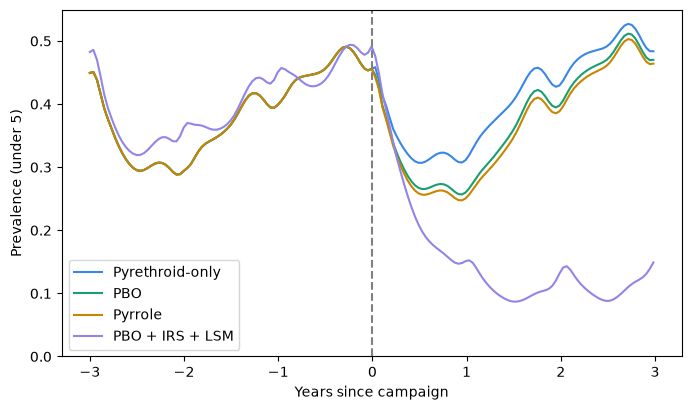

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))

for _, row in results.iterrows():
    ax.plot(years, row["prevalence"], label=row["name"])

ax.axvline(0, color="grey", ls="--")
ax.set_xlabel("Years since campaign")
ax.set_ylabel("Prevalence (under 5)")
ax.set_ylim(0, None)
ax.legend()

plt.show()

Only the three net scenarios share the run-up on the left, since the purple combination starts from
its own higher baseline. After the campaign it drops far below the others and stays there, because
spraying and larviciding do not decay on a net's clock.

## Clinical cases

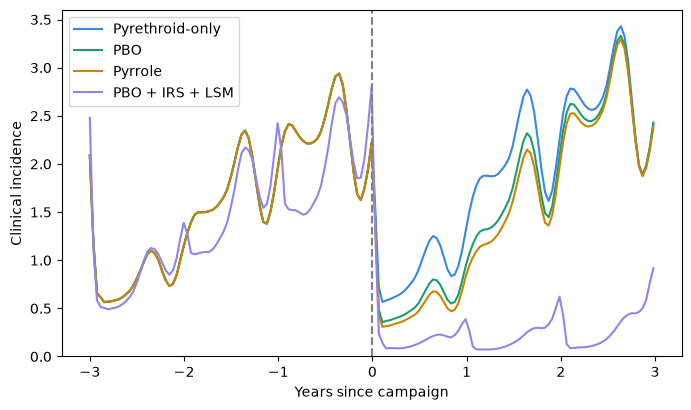

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))

for _, row in results.iterrows():
    ax.plot(years, row["cases"], label=row["name"])

ax.axvline(0, color="grey", ls="--")
ax.set_xlabel("Years since campaign")
ax.set_ylabel("Clinical incidence")
ax.set_ylim(0, None)
ax.legend()

plt.show()

Incidence swings from step to step. The three net-only scenarios climb back over the campaign as
their insecticide fades, while the combination stays low.

## Cases averted

The last step on its own is noisy and misleading, so add up the cases from the campaign onwards and
compare each upgrade with the like-for-like pyrethroid replacement.

In [8]:
rows = []
for _, row in results.iterrows():
    total = float(row["cases"][campaign:].sum()) * step_days
    rows.append({"name": row["name"], "total_cases": total})

table = pd.DataFrame(rows).set_index("name")

baseline = table.loc["Pyrethroid-only", "total_cases"]
table["averted"] = baseline - table["total_cases"]
table["averted_pct"] = 100 * table["averted"] / baseline

table.sort_values("averted", ascending=False).round(1)

,total_cases,averted,averted_pct
name,,,
PBO + IRS + LSM,307.1,1776.3,85.3
Pyrrole,1692.3,391.1,18.8
PBO,1789.8,293.6,14.1
Pyrethroid-only,2083.4,0.0,0.0


Upgrading from the like-for-like replacement to PBO or pyrrole averts a modest share of the cases,
and the full package averts most of them. The ranking follows `dn0_future`, so it is only as good as
the resistance estimate behind it.

## Mosquito density

The pipeline works the EIR and the human biting rate out for itself, so `EirTarget` almost always
carries a prevalence from a survey rather than either of those. What a programme can supply is a
change in the number of mosquitoes, after a wet year, an irrigation scheme, or a round of larviciding.
`mosquito_delta` on a `Scenario` applies that change as a proportion, so `0.50` is half as many again
and `-0.50` is half as many. Hold the PBO campaign fixed and sweep it.

In [9]:
pbo = replace(base, name="PBO", net_type_future="pyrethroid_pbo", itn_future=0.70)

deltas = [-0.50, -0.25, 0.0, 0.25, 0.50]
mosquito = run_scenarios([
    replace(pbo, name=("baseline" if d == 0 else f"{d:+.0%}"), mosquito_delta=d)
    for d in deltas
])

mosquito[["name", "mosquito_delta", "eir_baseline", "eir_final",
          "prev_y9", "prev_endline"]].round(2)

,name,mosquito_delta,eir_baseline,eir_final,prev_y9,prev_endline
0,-50%,-0.50,31.96,16.36,0.34,0.36
1,-25%,-0.25,31.96,24.10,0.41,0.42
2,baseline,0.00,31.96,31.96,0.46,0.47
3,+25%,0.25,31.96,41.83,0.50,0.52
4,+50%,0.50,31.96,52.04,0.54,0.55


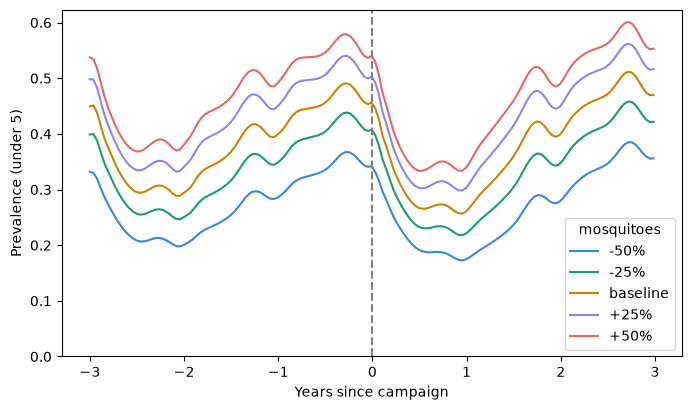

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))

for _, row in mosquito.iterrows():
    ax.plot(years, row["prevalence"], label=row["name"])

ax.axvline(0, color="grey", ls="--")
ax.set_xlabel("Years since campaign")
ax.set_ylabel("Prevalence (under 5)")
ax.set_ylim(0, None)
ax.legend(title="mosquitoes")

plt.show()

More mosquitoes raise prevalence and fewer lower it.

## Export

Two columns hold arrays and will not fit a CSV cell, so save the scalars and the trajectories in
separate files. The long trajectory file is the shape `ggplot2` and `dplyr` expect.

In [11]:
os.makedirs("outputs", exist_ok=True)

results.drop(columns=["prevalence", "cases"]).to_csv("outputs/summary.csv", index=False)

frames = []
for _, row in results.iterrows():
    frames.append(pd.DataFrame({
        "name": row["name"], "day": day, "years": years,
        "prevalence": row["prevalence"], "cases": row["cases"],
    }))

pd.concat(frames, ignore_index=True).to_csv("outputs/trajectories.csv", index=False)

print("wrote outputs/summary.csv and outputs/trajectories.csv")

wrote outputs/summary.csv and outputs/trajectories.csv


Read the trajectories straight into R.

```r
library(readr)
library(ggplot2)

traj <- read_csv("outputs/trajectories.csv")

ggplot(traj, aes(years, prevalence, colour = name)) +
  geom_line() +
  geom_vline(xintercept = 0, linetype = "dashed") +
  theme_minimal()
```

Please see [Running scenarios](https://cosmonaught.github.io/MINTverse/chapters/06-scenarios/run-scenarios.html)
for every `Scenario` field, and [Trajectories and
cases](https://cosmonaught.github.io/MINTverse/chapters/06-scenarios/comparing.html) for the plots
and the burden in more depth.